#### Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

#### Useful functions/classes

In [9]:
### Takes a volume and splits it into cubes (blocks) of a specified dimension. Returns
### a list of torch tensors, each representing one block of the volume. If block_dim
### does not divide equally into the volume dimensions, creates blocks that extend past the
### dimensions of the volume, and populates the coordinates outside the volume with junk,
### which is an input to the function
def to_blocks(volume, block_dim, junk):
    
    xdim = volume.shape[0]
    ydim = volume.shape[1]
    zdim = volume.shape[2]

    # Determine number of blocks necessary in each dimension to cover volume
    # Creates extra blocks if block_dim doesn't divide evenly into volume dims
    x_steps = int(xdim // block_dim)
    if xdim % block_dim != 0:
        x_steps += 1
    y_steps = int(ydim / block_dim)
    if ydim % block_dim != 0:
        y_steps += 1
    z_steps = int(zdim / block_dim)
    if zdim % block_dim != 0:
        z_steps += 1
    num_blocks = int(x_steps * y_steps * z_steps)

    # Storage list for blocks
    blocks = []

    # Iterate over each necessary block
    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):

                # Figure out the initial dimensions of the current block
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)

                # Storage tensor for block data
                block = torch.empty((block_dim, block_dim, block_dim))

                # Iterate through the block and populate it with data
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):

                            # If coordinates are beyond the volume, populate with junk
                            if (x_lo + x) >= xdim:
                                block[x][y][z] = junk
                            elif (y_lo + y) >= ydim:
                                block[x][y][z] = junk
                            elif (z_lo + z) >= zdim:
                                block[x][y][z] = junk
                            else:
                                block[x][y][z] = volume[x_lo + x][y_lo + y][z_lo + z]

                blocks.append(block)

    return blocks


### Reads volume files in input_dir up to a maximum time step (max), and stores them in a nested
### list of format all_data[time_step][block_idx][x][y][z]
def process_data(input_dir, min_file, max_file, xdim, ydim, zdim, component, block_dim, junk):

    # Check if block_dim is a power of 2 (necessary for convolutional autoencoder)
    if not math.log2(block_dim).is_integer():
        print("Invalid block_dim! Dimension must be a power of 2.")
        return

    # Set up nested list to store data
    all_data = []

    for t in range(min_file, max_file): # iterate over each time step
        filename = input_dir + str(t) + "-whole-" + str(component) + ".raw"
        with open(filename, "rb") as file:
            # storage array for volume data
            volume = np.empty((xdim, ydim, zdim))
            for k in range(zdim): # iterate through volume
                for j in range(ydim):
                    for i in range(xdim):
                        volume[i][j][k] = struct.unpack('<f', file.read(4))[0]
            # Convert volume to blocks of specified dimension
            blocks = to_blocks(volume, block_dim, junk)
            all_data.append(blocks)
        print("Processed data from time step",str(t))
        
    return all_data


### Assembles processed data into samples that can be used to train an autoencoder. Returns
### torch tensors with dimensions num_samples x 1 x block_dim x block_dim x block_dim; note
### that input and output are the same when training an autoencoder, so returns two instances
### of inputs
def create_samples(data):
    inputs = []
    for t in range(len(data)):
        tdata = data[t]
        for l in range(len(tdata)):
            inputs.append(np.array(tdata[l]))

    inputs = np.array(inputs)
    inputs = torch.tensor(inputs, dtype=torch.float32)
    inputs = inputs[:, None, :, :, :]
    return inputs, inputs
    

class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        self.X_full = X_full
        self.y_full = y_full

    def __len__(self):
        return len(self.X_full)

    def __getitem__(self, idx):
        input = self.X_full[idx]
        output = self.y_full[idx]
        return input, output

#### Hyperparameters

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
batch_size = 32
epochs = 2500

Running on cuda


In [11]:
data = process_data("wholeVolumes-6/", 74, 84, 256, 96, 96, 6, 32, 0)
x, y = create_samples(data)
print(x.shape)
print(y.shape)

# Scale the data to be between 0 and 1
xmin = x.min()
xmax = x.max()
ymin = y.min()
ymax = y.max()
xnormal = (x - xmin) / (xmax - xmin)
ynormal = (y - ymin) / (ymax - ymin)

# Initialize the dataset, and create data loader
dataset = CombustionData(xnormal, ynormal)
train_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

Processed data from time step 74
Processed data from time step 75
Processed data from time step 76
Processed data from time step 77
Processed data from time step 78
Processed data from time step 79
Processed data from time step 80
Processed data from time step 81
Processed data from time step 82
Processed data from time step 83
torch.Size([720, 1, 32, 32, 32])
torch.Size([720, 1, 32, 32, 32])


#### Model Initialization

In [1]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 256, kernel_size=3, stride=2, padding=1), # Output: 64 channels, block_dim/2
            nn.ReLU(),
            nn.Conv3d(256, 512, kernel_size=3, stride=2, padding=1), # Output: 128 channels, block_dim/4
            nn.ReLU(),
            nn.Conv3d(512, 1024, kernel_size=3, stride=2, padding=1), # Output: 256 channels, block_dim/8
            #nn.ReLU(),
            #nn.Conv3d(512, 1024, kernel_size=3, stride=2, padding=1), # Output: 512 channels, block_dim/16
            #nn.ReLU(),
            #nn.Conv3d(512, 1024, kernel_size=3, stride=2, padding=1) # Output: 1024 channels, block_dim/32
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(1024, 512, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 512 channels, block_dim/16
            nn.ReLU(),
            nn.ConvTranspose3d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 256 channels, block_dim/8
            nn.ReLU(),
            nn.ConvTranspose3d(256, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 128 channels, block_dim/4
            #nn.ReLU(),
            #nn.ConvTranspose3d(128, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 64 channels, block_dim/2
            #nn.ReLU(),
            #nn.ConvTranspose3d(64, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 1 channel, block_dim
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = ConvAutoencoder()

NameError: name 'nn' is not defined

#### Train model

In [16]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_hist = []

for epoch in range(epochs):
    losses = []
    for sample in train_loader:
        # Get the inputs
        inputs = sample[0]

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute the loss
        loss = criterion(outputs, inputs)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_hist.append(np.mean(losses))
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {loss:.8f}")

Epoch 10/2500: Training Loss = 0.00182893
Epoch 20/2500: Training Loss = 0.00136969
Epoch 30/2500: Training Loss = 0.00099538
Epoch 40/2500: Training Loss = 0.00082421
Epoch 50/2500: Training Loss = 0.00064284
Epoch 60/2500: Training Loss = 0.00046089
Epoch 70/2500: Training Loss = 0.00050756
Epoch 80/2500: Training Loss = 0.00049414
Epoch 90/2500: Training Loss = 0.00069217
Epoch 100/2500: Training Loss = 0.00041914
Epoch 110/2500: Training Loss = 0.00038004
Epoch 120/2500: Training Loss = 0.00041663
Epoch 130/2500: Training Loss = 0.00029127
Epoch 140/2500: Training Loss = 0.00035060
Epoch 150/2500: Training Loss = 0.00040467
Epoch 160/2500: Training Loss = 0.00027144


KeyboardInterrupt: 

#### Plot loss

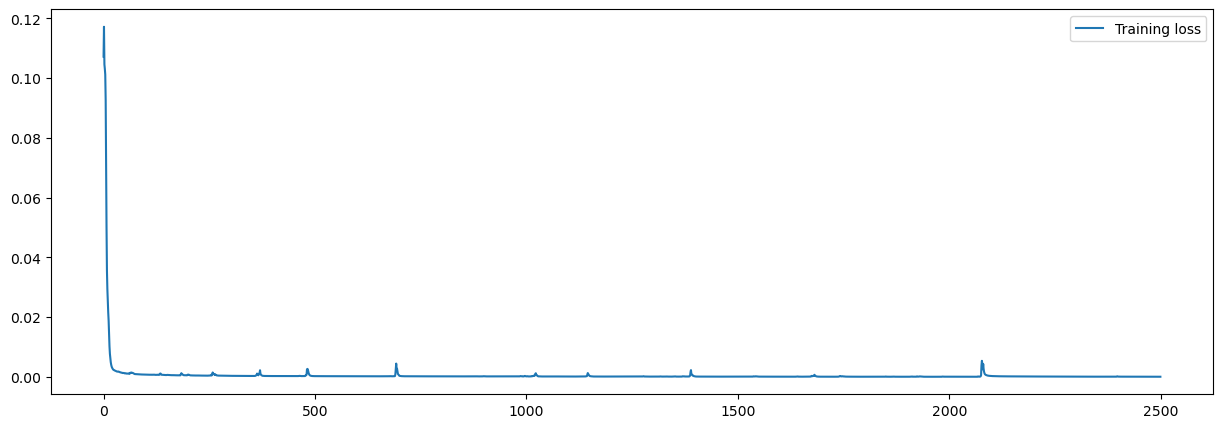

In [7]:
plt.figure(figsize=(15,5))
plt.plot(range(2500), train_hist, label='Training loss')
#plt.plot(range(31), val_hist, label='Validation loss')
plt.legend()

#### Calc size of model

In [8]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 143.462MB


#### Save model

In [9]:
torch.save(model.state_dict(), "testModels/model1.pt")

#### Generate timestep using learned model

In [21]:
def generate_output(obs, model, step, block_dim, xdim, ydim, zdim):

    # Translate step from filename to actual position
    step = step - 74
    
    preds = [] # Ultimately 4608x1x512
    
    # Generate a prediction for each location using the model
    for l in range(len(obs[step])):
        input = obs[step][l]
        input = input[None, :, :, :]
        normal_input = (input - xmin) / (xmax - xmin)
        pred = model(normal_input)
        pred = pred.cpu().detach().numpy()
        preds.append(pred)

    # Unpack preds and reshape to be one volume
    preds = np.array(preds)
    preds = torch.tensor(preds, dtype=torch.float32).squeeze()
    preds = preds * (ymax - ymin) + ymin
    print(preds.shape)

    x_steps = int(xdim // block_dim)
    if xdim % block_dim != 0:
        x_steps += 1
    y_steps = int(ydim / block_dim)
    if ydim % block_dim != 0:
        y_steps += 1
    z_steps = int(zdim / block_dim)
    if zdim % block_dim != 0:
        z_steps += 1

    prediction = np.empty((xdim, ydim, zdim))
    block_num = 0

    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):
                            if (x_lo + x) < xdim and (y_lo + y) < ydim and (z_lo + z) < zdim:
                                prediction[x_lo + x][y_lo + y][z_lo + z] = preds[block_num][x][y][z]
                block_num += 1

    return prediction


# Retrieve and assemble the known output
def get_output(obs, step, block_dim, xdim, ydim, zdim):

    # Translate step from filename to actual position
    step = step - 74

    reals = []

    for l in range(len(obs[step])):
        real = obs[step][l]
        real = np.array(real)
        reals.append(real)

    reals = np.array(reals)
    reals = torch.tensor(reals, dtype=torch.float32)
    print(reals.shape)

    x_steps = int(xdim // block_dim)
    if xdim % block_dim != 0:
        x_steps += 1
    y_steps = int(ydim / block_dim)
    if ydim % block_dim != 0:
        y_steps += 1
    z_steps = int(zdim / block_dim)
    if zdim % block_dim != 0:
        z_steps += 1

    actual = np.empty((xdim, ydim, zdim))
    block_num = 0

    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):
                            if (x_lo + x) < xdim and (y_lo + y) < ydim and (z_lo + z) < zdim:
                                actual[x_lo + x][y_lo + y][z_lo + z] = reals[block_num][x][y][z]
                block_num += 1

    return actual

In [22]:
prediction = generate_output(data, model, 80, 64, 256, 96, 96)
actual = get_output(data, 80, 64, 256, 96, 96)

torch.Size([16, 64, 64, 64])
torch.Size([16, 64, 64, 64])


In [23]:
def calc_mse(actual, predicted):

    xdim = actual.shape[0]
    ydim = actual.shape[1]
    zdim = actual.shape[2]

    sum = 0

    for k in range(zdim):
        for j in range(ydim):
            for i in range(xdim):
                sq = (actual[i][j][k] - predicted[i][j][k])**2
                sum += sq

    mse = sum / (xdim * ydim * zdim)

    return mse

mse = calc_mse(actual, prediction)
rmse = mse**0.5
print(rmse)

25.901153745215684


In [55]:
var = torch.std(y)
print(var)
print(ymin)
print(ymax)

tensor(1.8517e+09)
tensor(-2.6080e+10)
tensor(-3.9146e+09)


#### Write prediction and actual to be visualized

In [27]:
def write_to_visualize(volume, path, out_file):
    filename = path + out_file
    with open(filename, "wb") as file:
        volume.tofile(file)

delta = actual - prediction

write_to_visualize(prediction, "toVisualize/", "compression-prediction.raw")
write_to_visualize(actual, "toVisualize/", "compression-actual.raw")
write_to_visualize(delta, "toVisualize/", "compression-delta.raw")